In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.stats import iqr

warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
df=pd.read_excel("D:/ARTHI/prodigy info tech/bank-task3.xlsx")
df.rename(columns={'y':'deposit'},inplace=True)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  deposit    4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [4]:
df.shape

(4521, 17)

In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [6]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

In [7]:
df.dtypes.value_counts()

object    10
int64      7
Name: count, dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [10]:
cat_cols=df.select_dtypes(include='object').columns
print(cat_cols)

num_cols=df.select_dtypes(exclude='object').columns
print(num_cols)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')
Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


In [11]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [12]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,4521,4521,4521,4521,4521,4521,4521,4521,4521,4521
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,yes,no,cellular,may,unknown,no
freq,969,2797,2306,4445,2559,3830,2896,1398,3705,4000


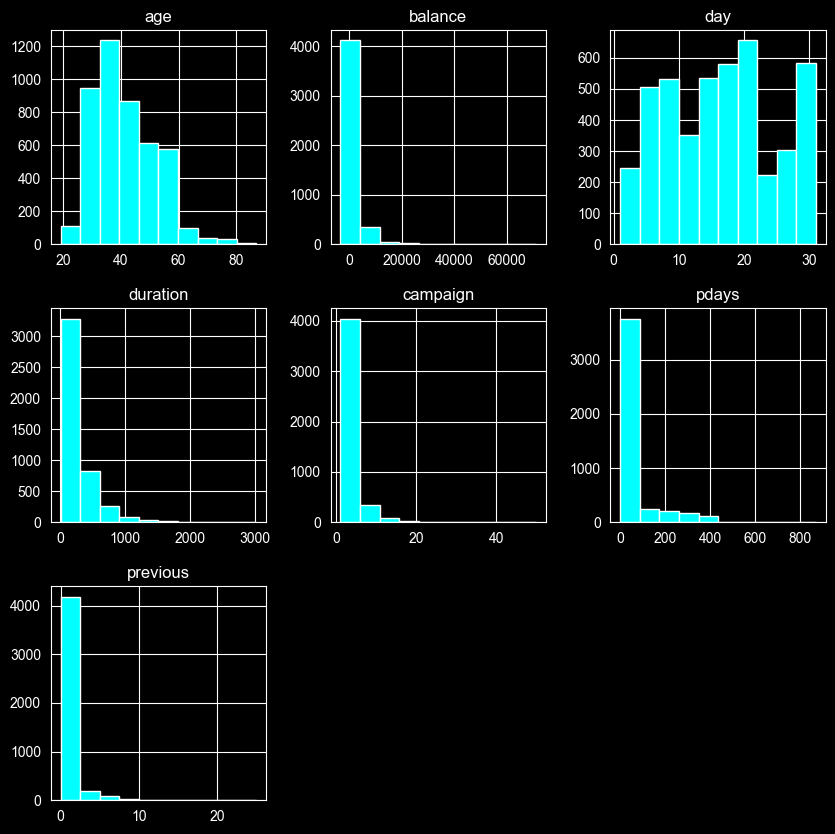

In [13]:
df.hist(figsize=(10,10),color='#00FFFF')
plt.show()

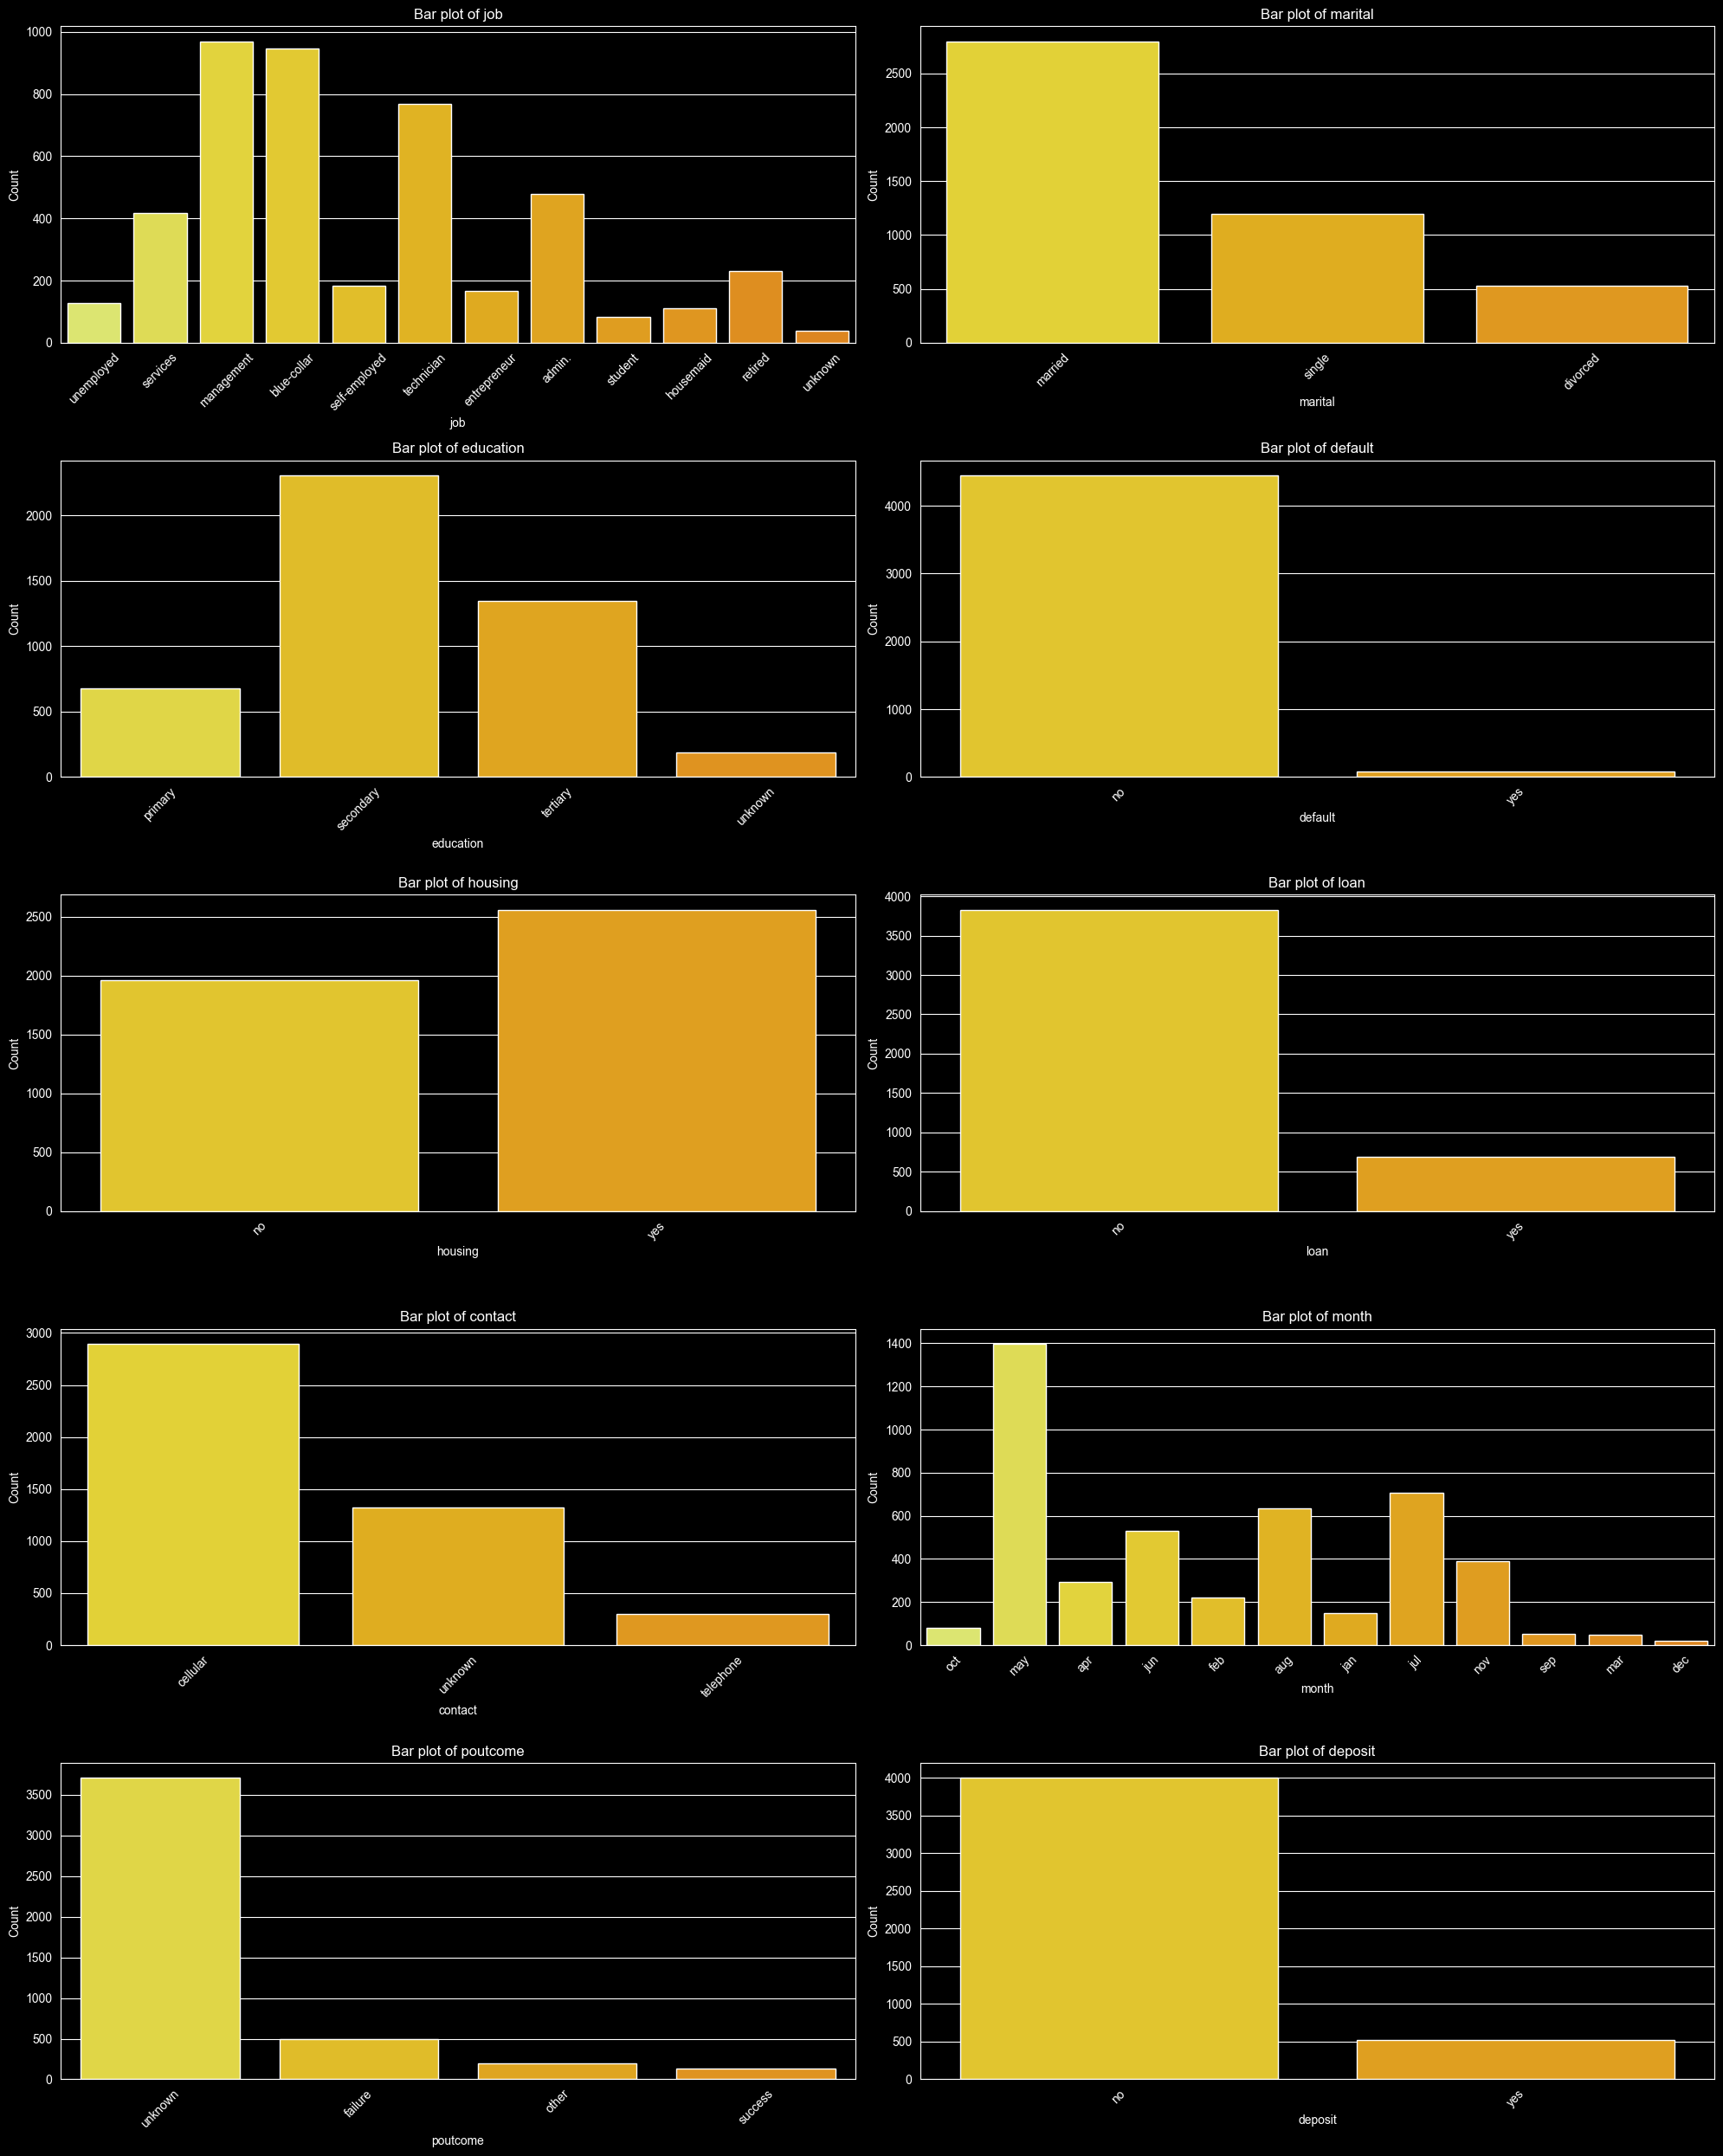

In [14]:
num_plots=len(cat_cols)
num_rows=(num_plots+1)//2
num_cols=2
plt.figure(figsize=(20,25))
for i, feature in enumerate(cat_cols,1):
    plt.subplot(num_rows,num_cols,i)
    sns.countplot(x=feature,data=df,palette='Wistia')
    plt.title(f'Bar plot of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

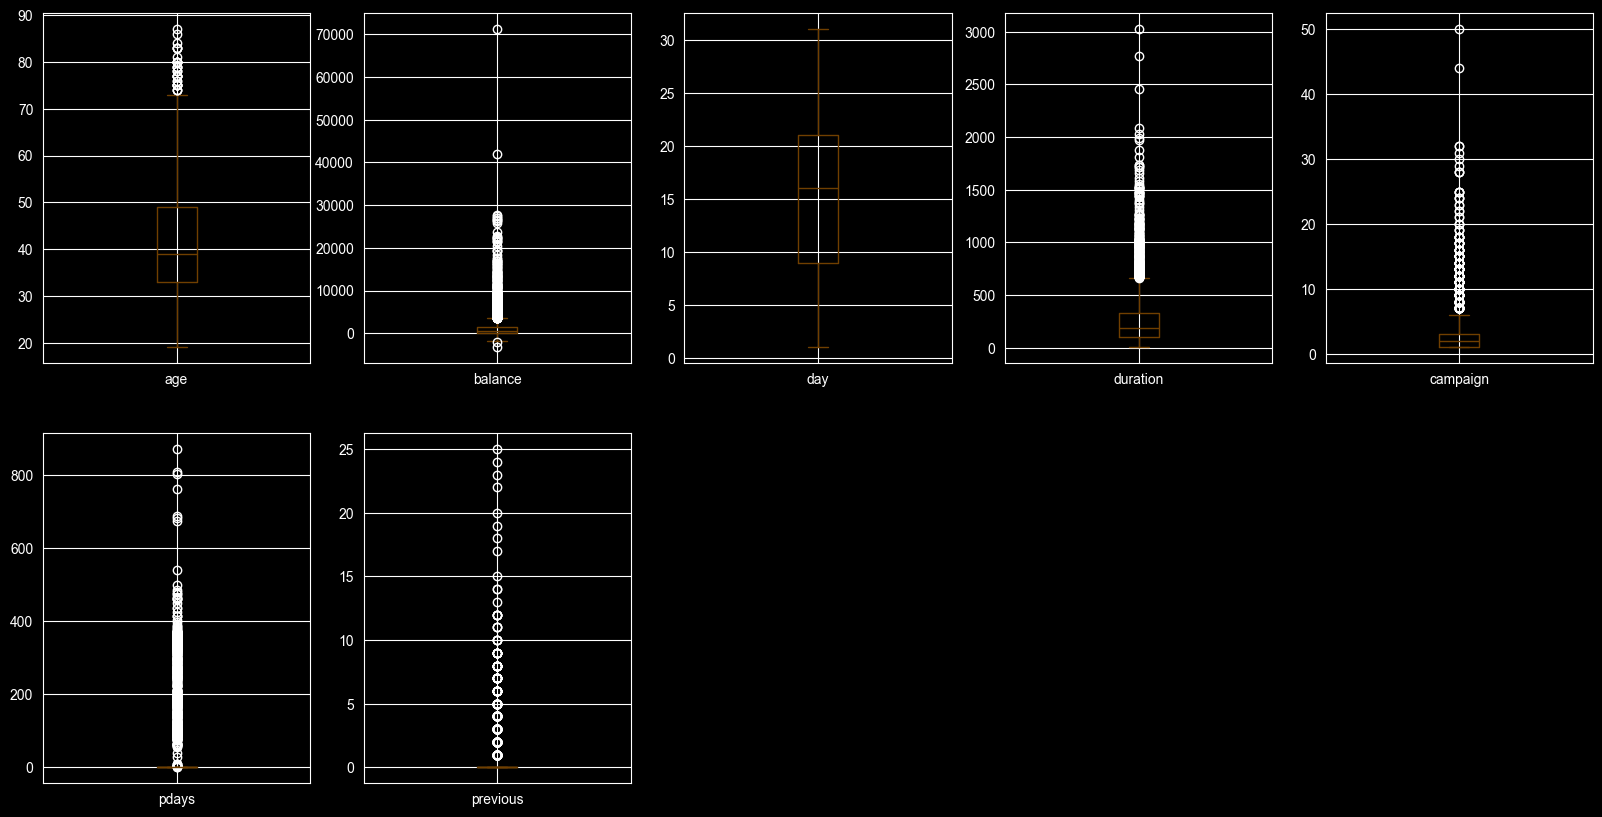

In [15]:
df.plot(kind='box',subplots=True,layout=(2,5),figsize=(20,10),color='#703f00')
plt.show()

In [16]:
column=df[['age','campaign','duration']]
q1=np.percentile(column,25)
q3=np.percentile(column,75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3-1.5*iqr
df[['age','campaign','duration']]=column[(column>lower_bound)&(column<upper_bound)]

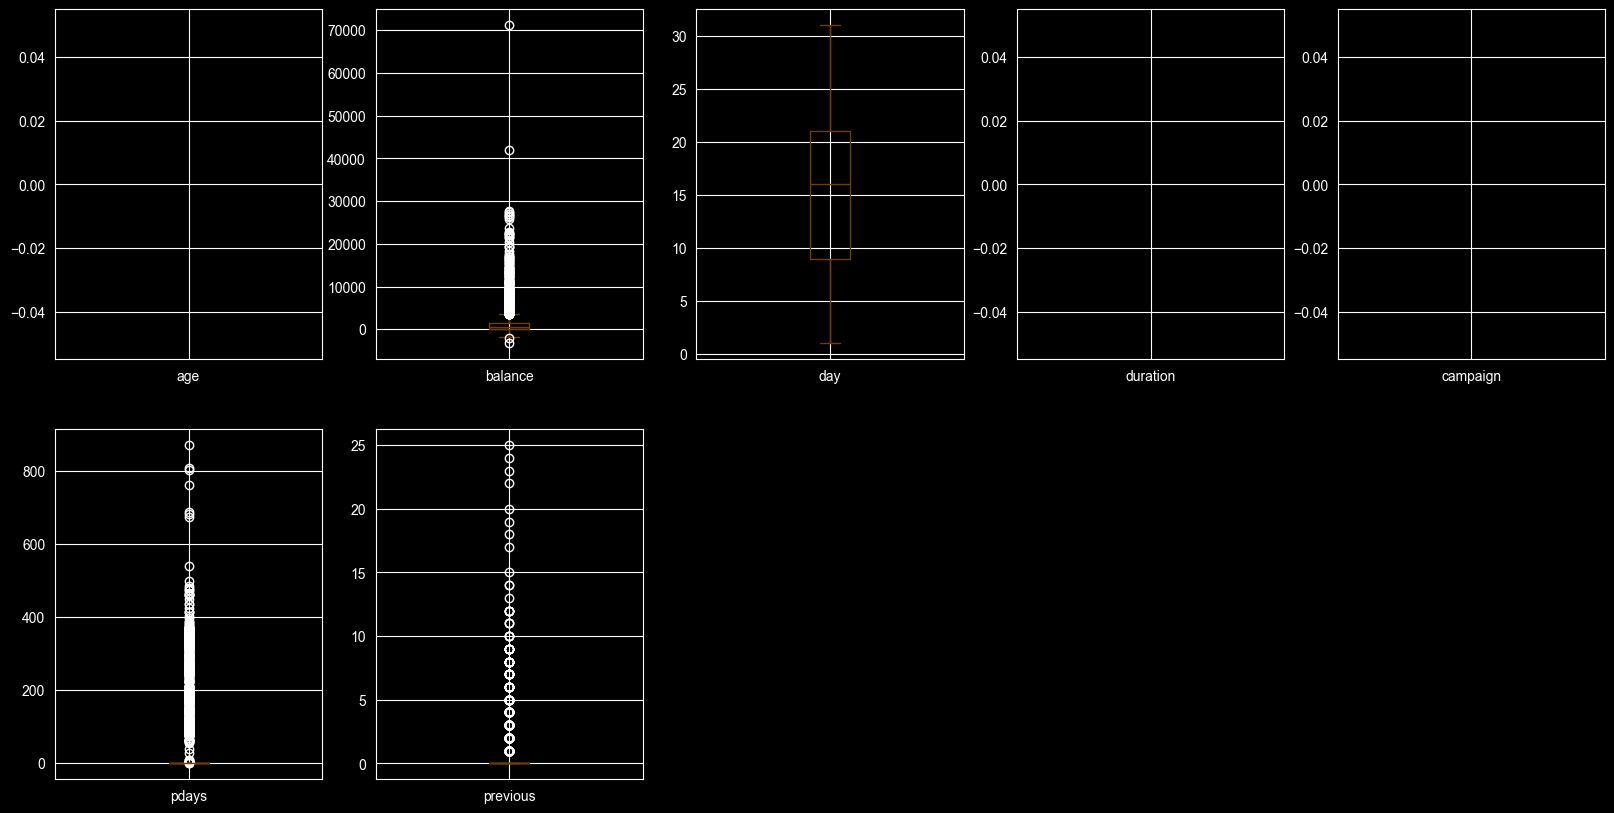

In [17]:
df.plot(kind='box',subplots=True ,layout=(2,5),figsize=(20,10),color='#703f00')
plt.show()

          age   balance       day  duration  campaign     pdays  previous
age       NaN       NaN       NaN       NaN       NaN       NaN       NaN
balance   NaN  1.000000 -0.008677       NaN       NaN  0.009437  0.026196
day       NaN -0.008677  1.000000       NaN       NaN -0.094352 -0.059114
duration  NaN       NaN       NaN       NaN       NaN       NaN       NaN
campaign  NaN       NaN       NaN       NaN       NaN       NaN       NaN
pdays     NaN  0.009437 -0.094352       NaN       NaN  1.000000  0.577562
previous  NaN  0.026196 -0.059114       NaN       NaN  0.577562  1.000000


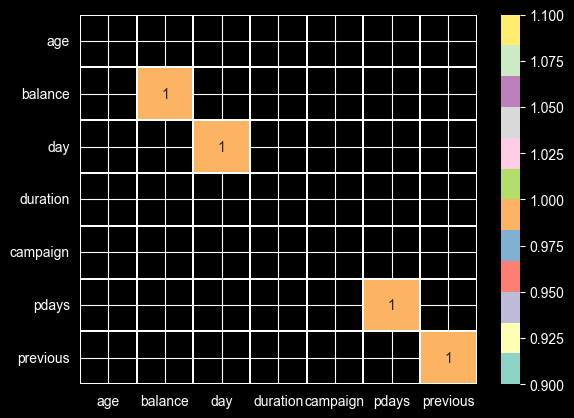

In [18]:
numeric_df=df.drop(columns=cat_cols)
corr=numeric_df.corr()
print(corr)
corr=corr[abs(corr)>=0.90]
sns.heatmap(corr,annot=True,cmap='Set3',linewidths=0.2)
plt.show()

In [19]:
high_corr_cols=['emp.var.rate','euribor3n','nr.employed']

In [20]:
df1=df.copy()
df1.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [21]:
df1.drop(high_corr_cols,axis=1,inplace=True)
df1.columns

KeyError: "['emp.var.rate', 'euribor3n', 'nr.employed'] not found in axis"

In [ ]:
df1.shape

In [ ]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
df_encoded=df1.apply(lb.fit_transform)
df_encoded

In [ ]:
df_encoded['deposit'].value_counts()

In [ ]:
x=df_encoded.drop('deposit',axis=1)
y=df_encoded['deposit']
print(x.shape)
print(y.shape)
print(type(x))
print(type(y))

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


In [ ]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
def eval_model(y_test,y_pred):
    acc=accuracy_score(y_test,y_pred)
    print("Accuracy_score:",acc)
    cm=confusion_matrix(y_test,y_pred)
    print("confusion_matrix:",cm)
    print("classification report:",classification_report(y_test,y_pred))

def mscore(model):
    train_score=model.score(x_train,y_train)
    test_score=model.score(x_test,y_test)
    print("training score:",train_score)
    print("test score:",test_score)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(criterion='gini',max_depth=5,min_samples_split=10)
dt.fit(x_train,y_train)

In [ ]:
mscore(dt)

In [ ]:
ypred_dt=dt.predict(x_test)
print(ypred_dt)

In [ ]:
eval_model(y_test,ypred_dt)

In [ ]:
from sklearn.tree import plot_tree

In [ ]:
cn=['no','yes']
fn=x_train.columns
print(fn)
print(cn)

In [ ]:
plt.figure(figsize=(30,10))
plot_tree(dt,class_names=cn,filled=True)
plt.show()

In [ ]:
dt1=DecisionTreeClassifier(criterion='entropy',max_depth=1,min_samples_split=15)
dt1.fit(x_train,y_train)

In [ ]:
mscore(dt1)

In [ ]:
ypred_dt1=dt1.predict(x_test)

In [ ]:
eval_model(y_test,ypred_dt1)

In [ ]:
plt.figure(figsize=(40,20))
plot_tree(dt,class_names=cn,filled=True)
plt.show()